# Phase 1: Loading, Exploring and Cleaning the Datasets

In [1]:
import pandas as pd

# Loading data
train_trans = pd.read_csv('../data/raw/train_transaction.csv')
train_id = pd.read_csv('../data/raw/train_identity.csv')

# Merging on TransactionID
train = pd.merge(train_trans, train_id, on='TransactionID', how='left')

print("Data successfully loaded and merged...")
print(f"Total rows: {len(train)}")
print(f"Train dataset shape: {train.shape}")

Data successfully loaded and merged...
Total rows: 590540
Train dataset shape: (590540, 434)


In [2]:
# Calculating the percentage of missing values for each feature
missing_percentages = (train.isnull().sum() / len(train)) * 100

# Sorting the results in descending order
missing_percentages = missing_percentages.sort_values(ascending=False)

# Top 30 features with most missing values
print('Top 30 features with most missing values: ')
print(missing_percentages.head(30))

Top 30 features with most missing values: 
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
D8       87.312290
id_10    87.312290
D9       87.312290
id_30    86.865411
id_32    86.861855
id_34    86.824771
id_14    86.445626
V138     86.123717
V139     86.123717
V148     86.123717
dtype: float64


In [3]:
# Dropping features with more than 99% of missing data
features_to_drop = missing_percentages[missing_percentages > 99].index

# Drop those columns
train = train.drop(columns=features_to_drop)
print(f"Total features dropped: {len(features_to_drop)}")
print(f"New Train dataset shape: {train.shape}")

Total features dropped: 9
New Train dataset shape: (590540, 425)


# Phase 2: Feature Engineering
## Target and Label Encodings
## Group Aggregations
## Preventing data fragmentation


In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold

print("Starting memory-optimized feature engineering pipeline...")

# Initializing a blank dictionary to collect columns in background memory
new_features = {}

# Computing Cyclical Time Features
new_features['hour_of_day'] = (train['TransactionDT'] // 3600) % 24
new_features['day_of_week'] = (train['TransactionDT'] // (3600 * 24)) % 7

# Setting up Automated Sorting for Encodings
categorical_cols = train.select_dtypes(include=['object', 'str', 'category']).columns
target_encode_cols = []
label_encode_cols = []

for col in categorical_cols:
    unique_count = train[col].nunique()
    if 100 < unique_count <= 1000:
        target_encode_cols.append(col)
    elif unique_count <= 100:
        label_encode_cols.append(col)

# Execute Leakage-Free K-Fold Target Encoding using raw NumPy structures
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in target_encode_cols:
    new_features[f'{col}_target_enc'] = np.empty(len(train))
    new_features[f'{col}_target_enc'][:] = np.nan

for train_idx, test_idx in kf.split(train):
    X_train_fold = train.iloc[train_idx]
    X_test_fold = train.iloc[test_idx]

    for col in target_encode_cols:
        col_probabilities = X_train_fold.groupby(col)['isFraud'].mean()
        new_features[f'{col}_target_enc'][test_idx] = X_test_fold[col].map(col_probabilities)

# Fill unmapped rare categories with the global average fraud rate
global_mean = train['isFraud'].mean()
for col in target_encode_cols:
    arr = new_features[f'{col}_target_enc']
    arr[np.isnan(arr)] = global_mean
    new_features[f'{col}_target_enc'] = arr

# Execute Label Encoding
for col in label_encode_cols:
    new_features[f'{col}_label_enc'] = train[col].astype('category').cat.codes

# 6. Compute Group Aggregations
new_features['card1_TransactionAmt_mean'] = train.groupby('card1')['TransactionAmt'].transform('mean')

# 7. Single-Step Concatenation: Build the new table and attach it side-by-side
new_features_df = pd.DataFrame(new_features, index=train.index)
train = pd.concat([train, new_features_df], axis=1)

print("All features engineered successfully with zero memory fragmentation!")
print(f"Final dataset shape: {train.shape}")

Starting memory-optimized feature engineering pipeline...
All features engineered successfully with zero memory fragmentation!
Final dataset shape: (590540, 456)


# Phase 3: Time - Based Split (80/20)

In [5]:
# Sorting the dataset chronologically
train = train.sort_values('TransactionDT').reset_index(drop=True)

# Finding the exact row index that represents the 80th percentile
split_index = int(len(train) * 0.8)

# ignoring these columns
drop_columns = ['isFraud', 'TransactionID', 'TransactionDT']

# Slicing the dataset into the 'Past' (Training) and 'Future' (Testing)
X_train = train.iloc[:split_index].drop(columns=drop_columns)
y_train = train.iloc[:split_index]['isFraud']

X_test = train.iloc[split_index:].drop(columns=drop_columns)
y_test = train.iloc[split_index:]['isFraud']

print("Split complete...")
print(f"Train dataset shape: {X_train.shape}")
print(f"Test dataset shape: {X_test.shape}")

Split complete...
Train dataset shape: (472432, 453)
Test dataset shape: (118108, 453)


# Phase 4: XGBoost Model, AUPRC

In [6]:
# Keep only the first instance of every column name and discard the duplicates
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

print("Duplicate columns removed safely!")
print(f"Clean X_train shape: {X_train.shape}")

Duplicate columns removed safely!
Clean X_train shape: (472432, 453)


In [7]:
# Finding all the columns with raw text (strings)
raw_txt_columns = X_train.select_dtypes(include=['object', 'str']).columns

# Dropping them from training and testing datasets
X_train = X_train.drop(columns=raw_txt_columns)
X_test = X_test.drop(columns=raw_txt_columns)

print(f"Dropped {len(raw_txt_columns)} raw text columns")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Dropped 29 raw text columns
X_train shape: (472432, 424)
X_test shape: (118108, 424)


Training the model on historical data...
Generating predictions on future data...
\nValidation AUPRC Score: 0.4860


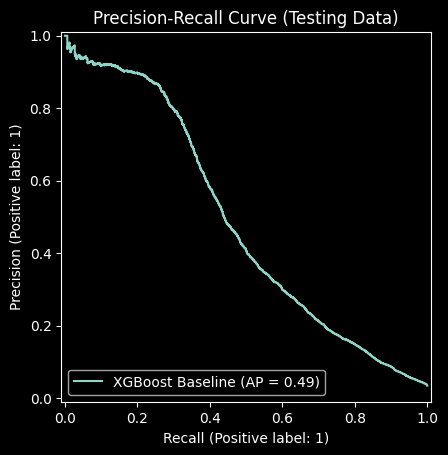

In [8]:
import xgboost as xgb
from sklearn.metrics import average_precision_score, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Calculating the fraud ratio to help the model balance its learning
fraud_ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Setting up the model architecture
classifier = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    tree_method='hist',
    scale_pos_weight=fraud_ratio,
    random_state=42,
    n_jobs=-1,
)

# model training
print("Training the model on historical data...")
classifier.fit(X_train, y_train)

# generating predictions on testing data
print("Generating predictions on future data...")
y_predict_proba = classifier.predict_proba(X_test)[:, 1]

# evaluation and visualization
auprc = average_precision_score(y_test, y_predict_proba)
print(f"\\nValidation AUPRC Score: {auprc:.4f}")

# Plotting the AUPRC curve
display = PrecisionRecallDisplay.from_predictions(y_test, y_predict_proba, name="XGBoost Baseline")
display.ax_.set_title("Precision-Recall Curve (Testing Data)")
plt.show()


Calculating Feature Importances...


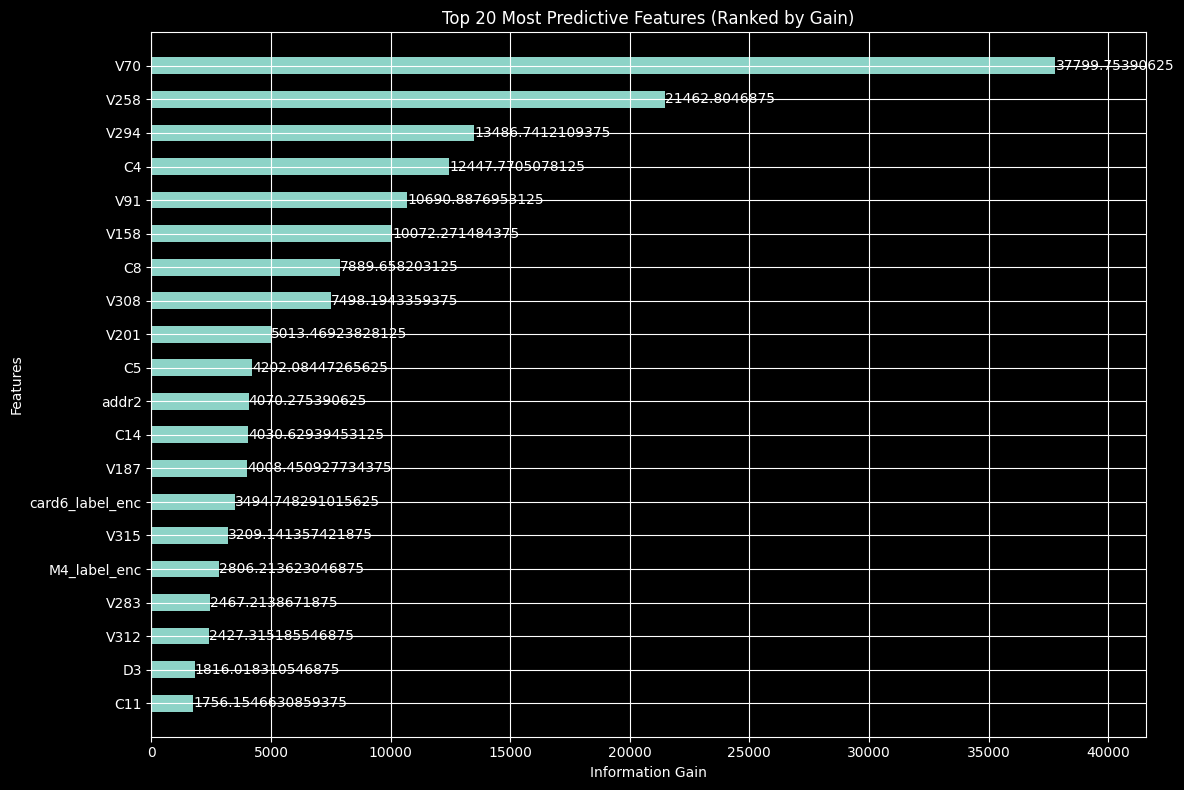

In [9]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

print("Calculating Feature Importances...")

# 1. Set up the plotting canvas
fig, ax = plt.subplots(figsize=(12, 8))

# 2. Plot the top 20 features, sorted by 'gain'
plot_importance(
    classifier,
    max_num_features=20,
    height=0.5,
    ax=ax,
    importance_type='gain',
    title='Top 20 Most Predictive Features (Ranked by Gain)',
    xlabel='Information Gain',
    ylabel='Features'
)

# 3. Display the graph cleanly
plt.tight_layout()
plt.show()

In [10]:
# Initializing the master dictionary
target_encode_maps = {}

# Calculate the absolute baseline fraud rate across the entire dataset
global_fraud_mean = train['isFraud'].mean()

for col in target_encode_cols:

    mapping = train.groupby(col)['isFraud'].mean().to_dict()

    mapping['global_mean'] = global_fraud_mean

    target_encode_maps[col] = mapping


In [11]:
import pickle
import os

# Define save path
save_dir = '../src/models/saved_models'
os.makedirs(save_dir, exist_ok=True)

# Serialize mapping dictionary
file_path = f"{save_dir}/target_encode_maps.pkl"

with open(file_path, "wb") as file:
    pickle.dump(target_encode_maps, file)

In [12]:
import os

# Ensure the processed data directory exists
export_dir = '../data/processed'
os.makedirs(export_dir, exist_ok=True)

# Define the exact file path
export_path = f"{export_dir}/train_engineered.csv"

print("Exporting engineered dataset to CSV")

# Saving dataframe to CSV file
train.to_csv(export_path, index=False)
print(f"Export complete. File saved to: {os.path.abspath(export_path)}")

Exporting engineered dataset to CSV


KeyboardInterrupt: 